<a href="https://colab.research.google.com/github/MoisesMartinPerez/JSON-ejemplo/blob/main/SNS_ACT3_4_Nasser_Mois%C3%A9s_Mart%C3%ADn_P%C3%A9rez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Autor: Nasser Moisés Martín Pérez

#2: Procesamiento de datos en el dataset: ajustes en características con datos no informados, conversión de variables categóricas, etc…


In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Descargar el dataset
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")
print("Path to dataset files:", path)

# Cargar el dataset
df = pd.read_csv(f"{path}/diabetes.csv")

# Reemplazar valores 0 en ciertas columnas por NaN (excepto Pregnancies y Outcome)
columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)

# Imputación de valores faltantes con la mediana
imputer = SimpleImputer(strategy="median")
df[columns_to_replace] = imputer.fit_transform(df[columns_to_replace])

# Normalización de los datos
scaler = StandardScaler()
df.iloc[:, :-1] = scaler.fit_transform(df.iloc[:, :-1])

# Guardar el dataset procesado
df.to_csv("diabetes_processed.csv", index=False)

print("Procesamiento completado. Archivo guardado como 'diabetes_processed.csv'.")

Path to dataset files: /root/.cache/kagglehub/datasets/akshaydattatraykhare/diabetes-dataset/versions/1
Procesamiento completado. Archivo guardado como 'diabetes_processed.csv'.


<ipython-input-4-537335a872ba>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.63994726 -0.84488505  1.23388019 -0.84488505 -1.14185152  0.3429808
 -0.25095213  1.82781311 -0.54791859  1.23388019  0.04601433  1.82781311
  1.82781311 -0.84488505  0.3429808   0.93691372 -1.14185152  0.93691372
 -0.84488505 -0.84488505 -0.25095213  1.23388019  0.93691372  1.53084665
  2.12477957  1.82781311  0.93691372 -0.84488505  2.7187125   0.3429808
  0.3429808  -0.25095213 -0.25095213  0.63994726  1.82781311  0.04601433
  2.12477957  1.53084665 -0.54791859  0.04601433 -0.25095213  0.93691372
  0.93691372  1.53084665  0.93691372 -1.14185152 -0.84488505 -0.54791859
  0.93691372  0.93691372 -0.84488505 -0.84488505  0.3429808   1.23388019
  0.93691372 -0.84488505  0.93691372 -1.14185152 -1.14185152 -1.14185152
 -0.54791859  1.23388019  0.3429808  -0.54791859  0.93691372  0.3429808
 -1.14185152 -0.54791859 -0.84488505  0.0460143

# 3. Utilizar las siguientes herramientas explicadas en clase para la selección de características:

**3.1. Matriz de gráficos de correlación.**

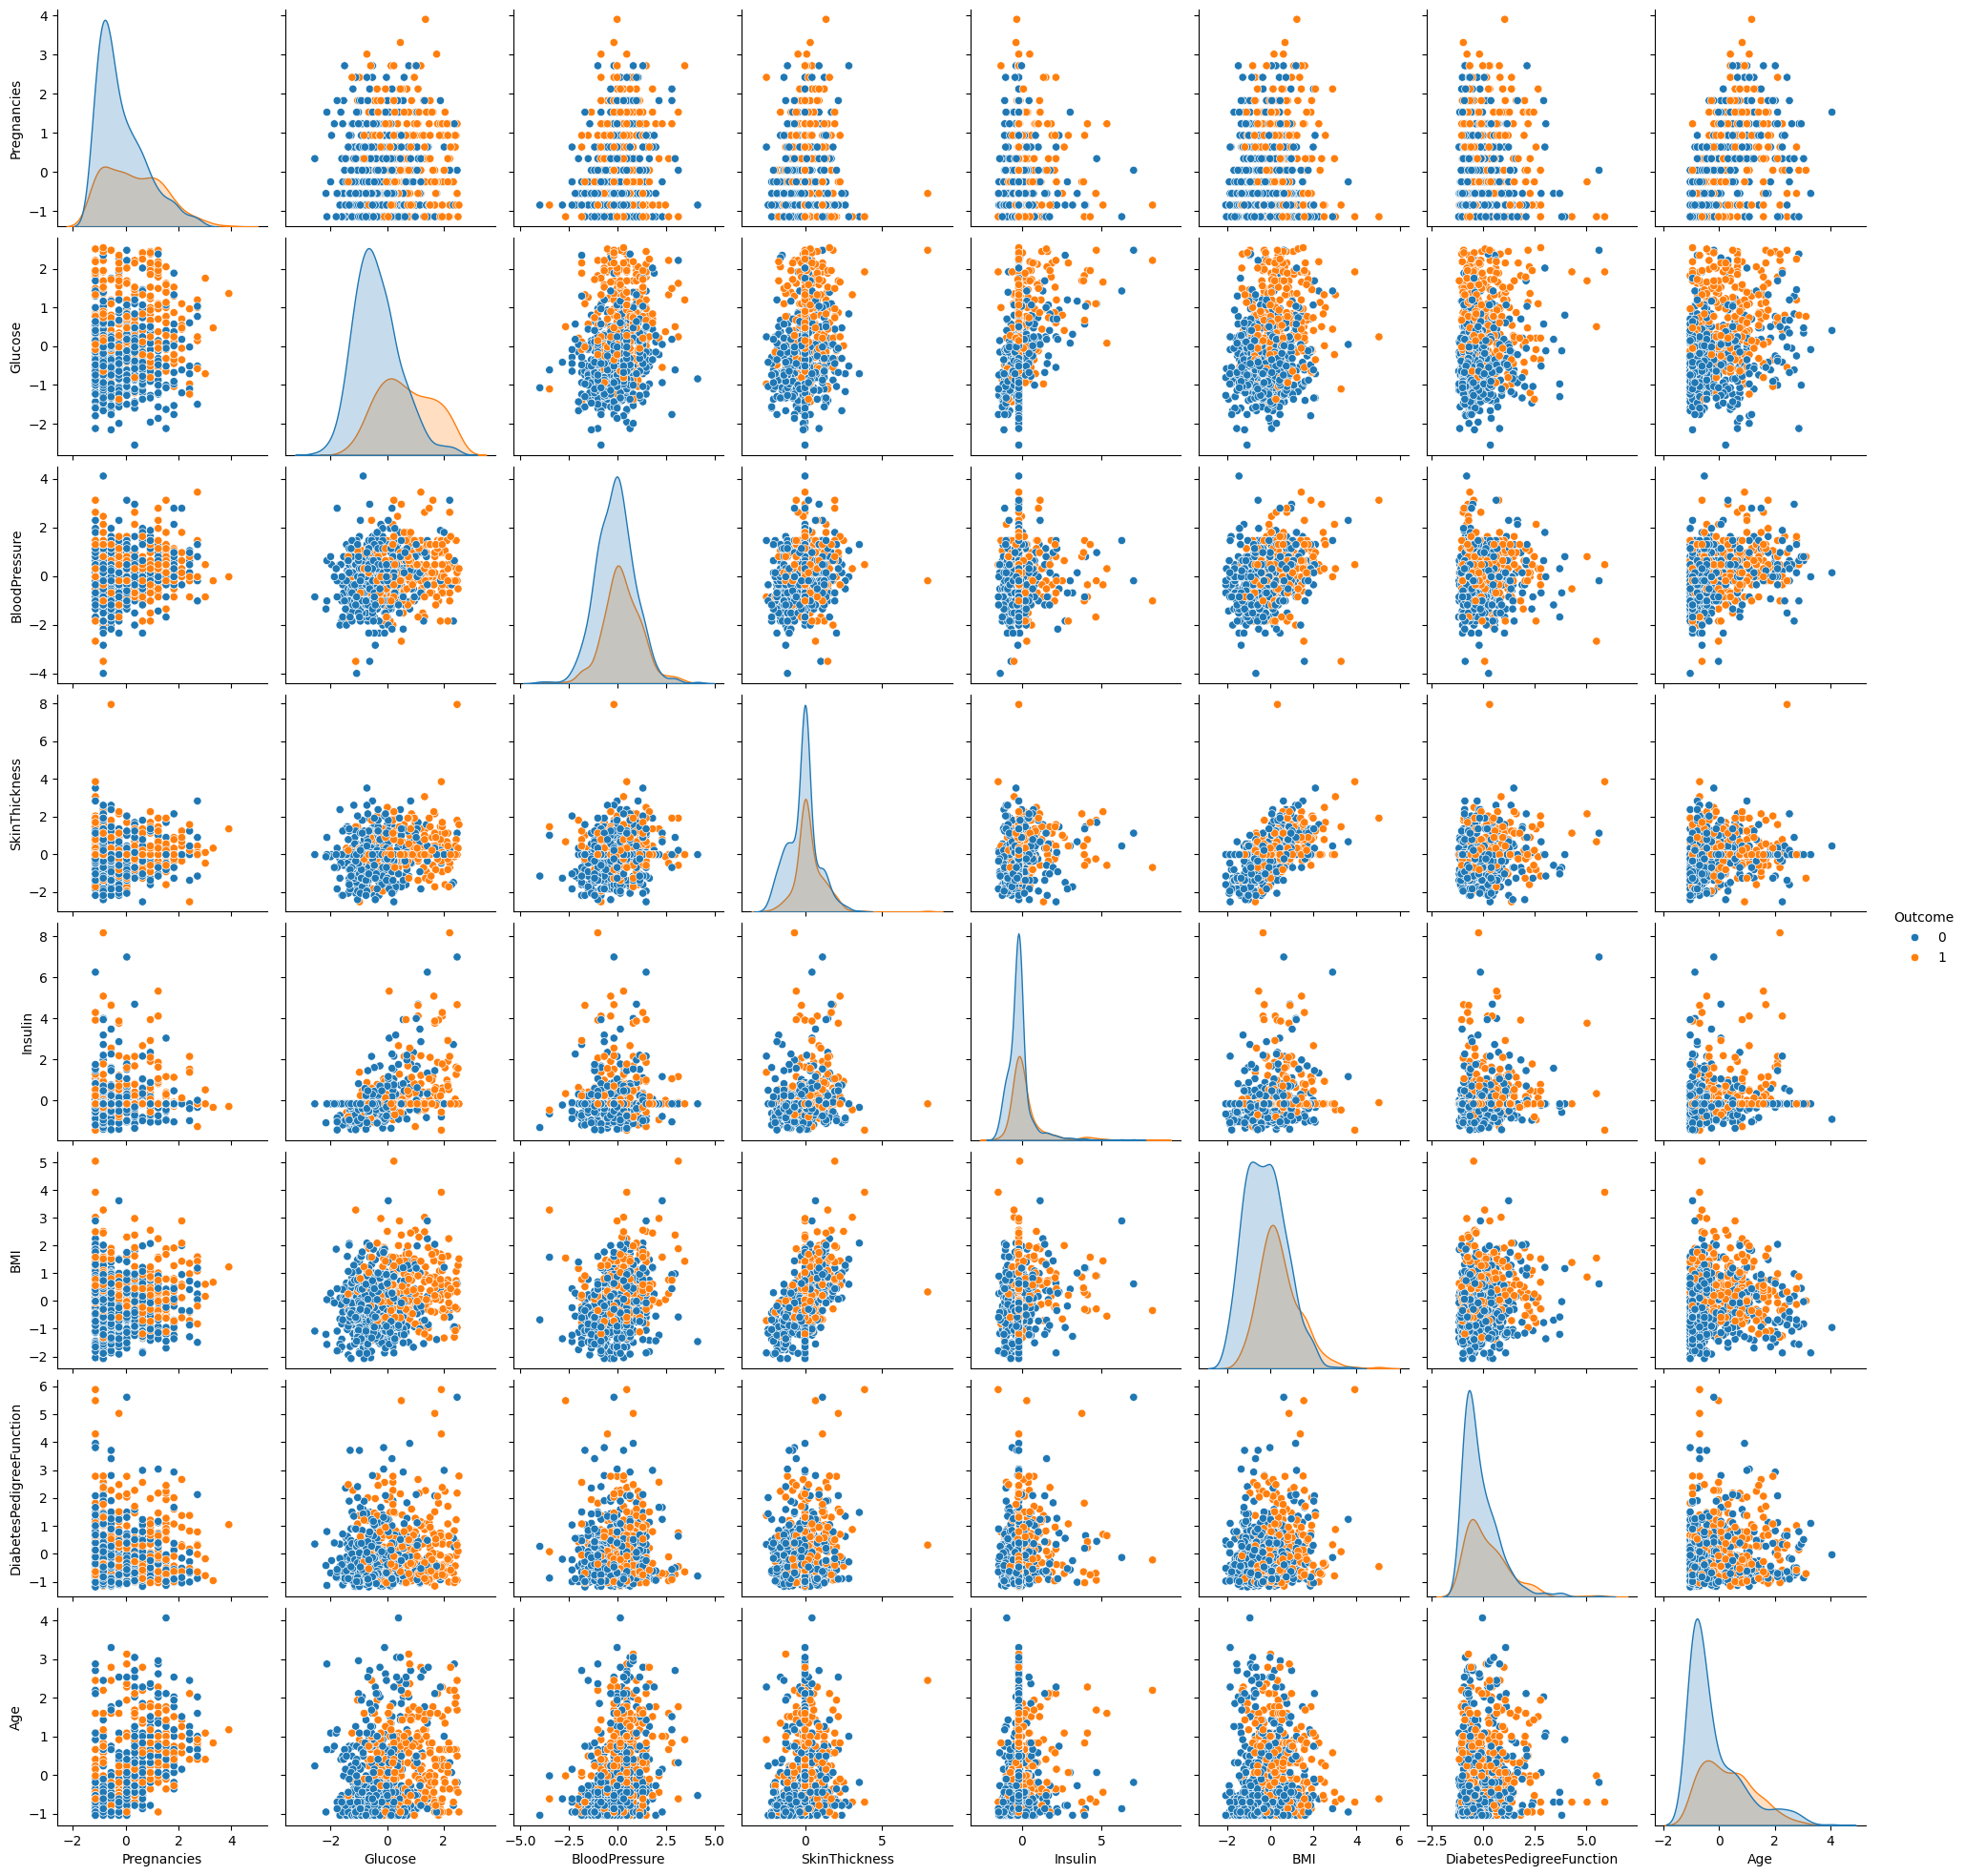

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de gráficos de correlación
sns.pairplot(df, hue="Outcome", diag_kind="kde")
plt.show()

**3.2. Matriz de gráficos de dispersión.**

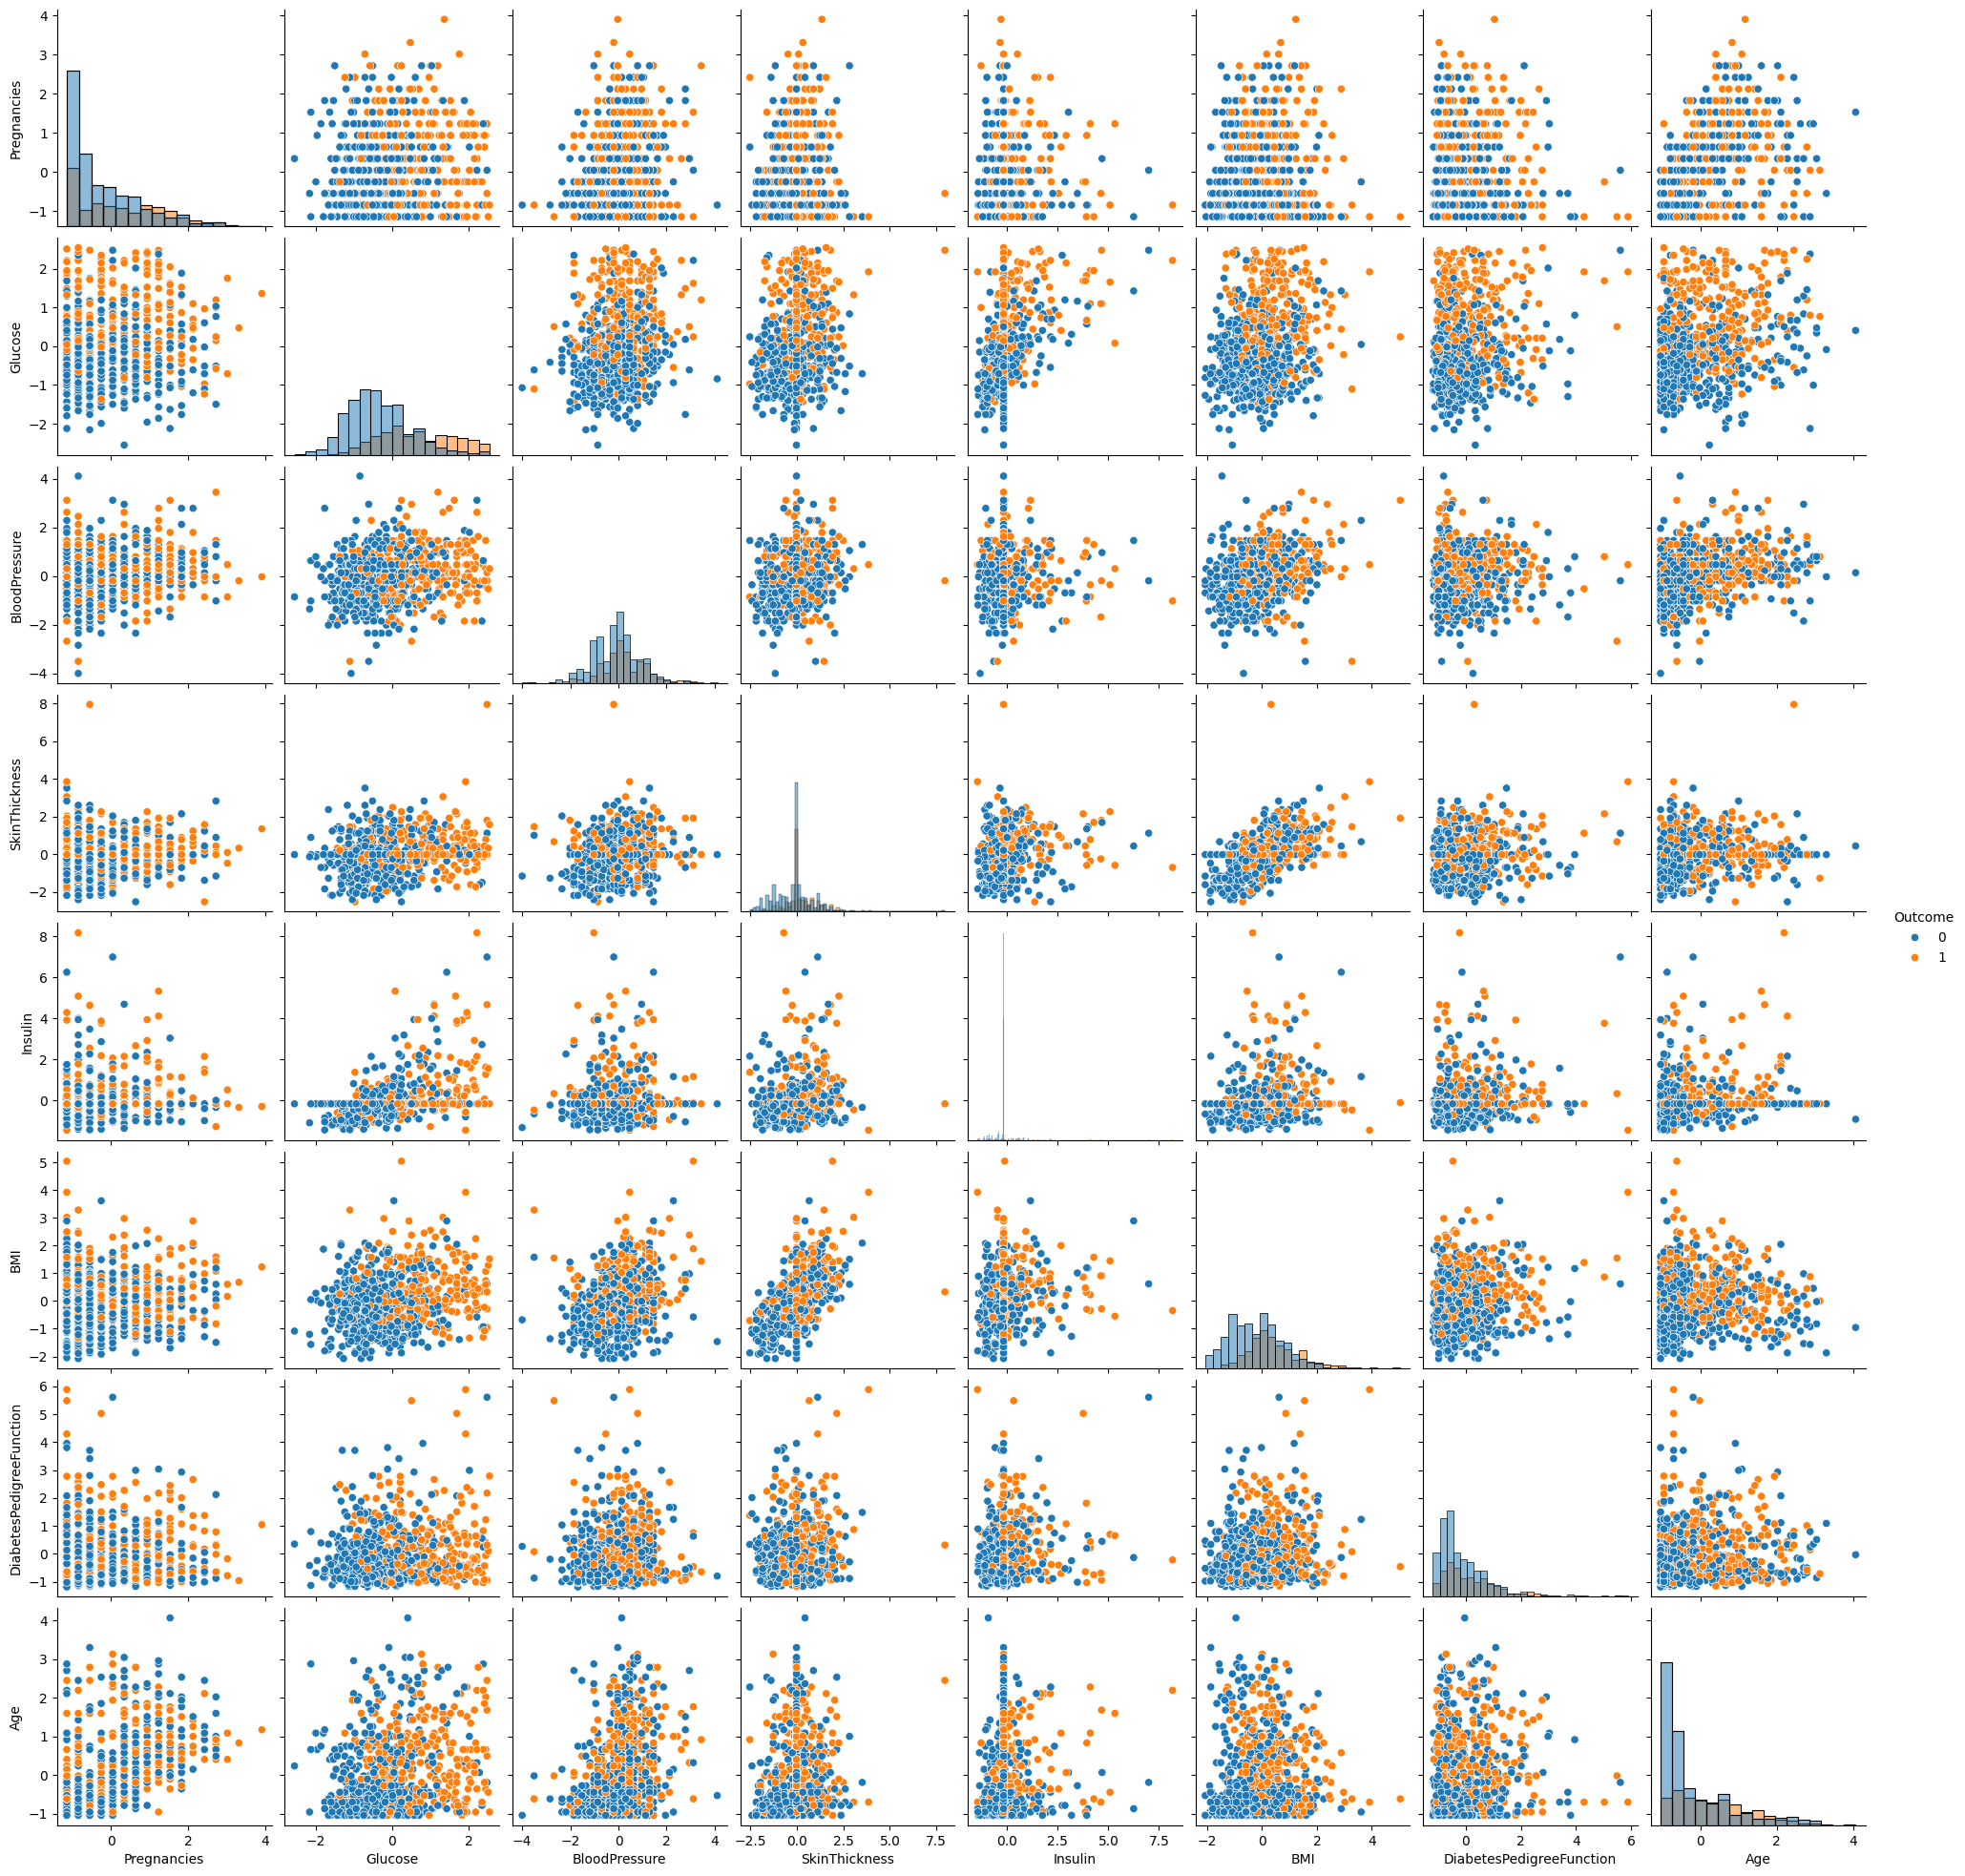

In [ ]:
# Matriz de gráficos de dispersión
sns.pairplot(df, hue="Outcome", diag_kind="hist", kind="scatter")
plt.show()

**3.3. SelectKBest.**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Selección de características con SelectKBest
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
selector = SelectKBest(score_func=f_classif, k=5)  # Seleccionar las 5 mejores características
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Mejores características seleccionadas:", selected_features.tolist())

# Guardar el dataset procesado
df_selected = pd.DataFrame(X_new, columns=selected_features)
df_selected["Outcome"] = y
df_selected.to_csv("diabetes_selected_features.csv", index=False)

print("Archivo con características seleccionadas guardado como 'diabetes_selected_features.csv'.")

Mejores características seleccionadas: ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age']
Archivo con características seleccionadas guardado como 'diabetes_selected_features.csv'.


#5. Con las librerías para NaiveBayes vistas en clase, entrenar el modelo que consideres más adecuado.

**5.1. Sin utilizar Cross Validation.**

Accuracy del modelo: 0.7013
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.64      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.70       154



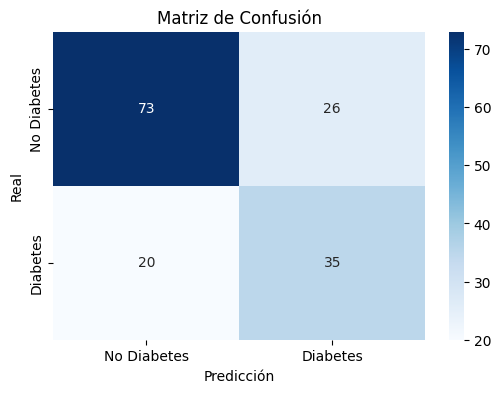

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Entrenar el modelo Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Evaluación del modelo
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy del modelo: {accuracy:.4f}")
print("Reporte de clasificación:")
print(report)

# Mostrar la matriz de confusión
title = "Matriz de Confusión"
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(title)
plt.show()

# Guardar el dataset procesado con características seleccionadas
df_selected = pd.DataFrame(X_new, columns=selected_features)
df_selected["Outcome"] = y
df_selected.to_csv("diabetes_selected_features.csv", index=False)


**5.2. Utilizando Cross Validation.**

Accuracy promedio con Cross Validation: 0.7579
Desviación estándar de la Accuracy: 0.0254
Accuracy en el conjunto de prueba: 0.7013
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.64      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.70       154



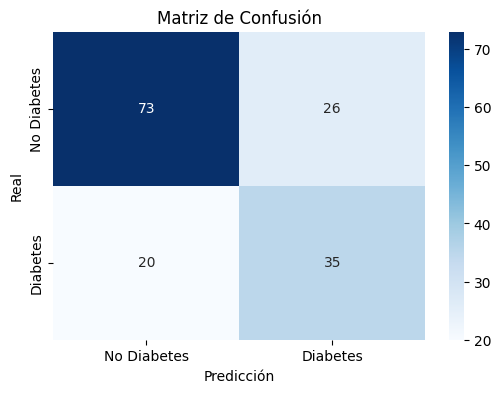

In [ ]:
from sklearn.model_selection import cross_val_score

# Entrenar el modelo Naive Bayes con Cross Validation
model = GaussianNB()
scores = cross_val_score(model, X_new, y, cv=5)  # 5-fold Cross Validation

print(f"Accuracy promedio con Cross Validation: {np.mean(scores):.4f}")
print(f"Desviación estándar de la Accuracy: {np.std(scores):.4f}")

# Entrenar y evaluar el modelo con datos divididos
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")
print("Reporte de clasificación:")
print(report)

# Mostrar la matriz de confusión
title = "Matriz de Confusión"
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(title)
plt.show()

# Guardar el dataset procesado con características seleccionadas
df_selected = pd.DataFrame(X_new, columns=selected_features)
df_selected["Outcome"] = y
df_selected.to_csv("diabetes_selected_features.csv", index=False)